# **Importing all the required Python Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# **Importing the IBM Telco Customer Dataset**

In [4]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# **Analyzing the dataset**

In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Checking for null values present in each column of the data**

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Checking for duplicate values present in each column of the data**

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [13]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [14]:
df['TotalCharges'].dtype

dtype('O')

**Correcting the null values present in the TotalCharges column**

In [15]:
(df['TotalCharges']==" ").sum()

np.int64(11)

In [16]:
df['TotalCharges']=df['TotalCharges'].replace(" ",np.nan)

In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
df['TotalCharges'].dtype

dtype('O')

In [19]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [20]:
df['TotalCharges'].dtype

dtype('float64')

In [21]:
df.fillna({'TotalCharges':df['TotalCharges'].mean()},inplace=True)

In [22]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# **Exploratory Data Analysis (EDA)**

**Checking the Target Variable Distribution**

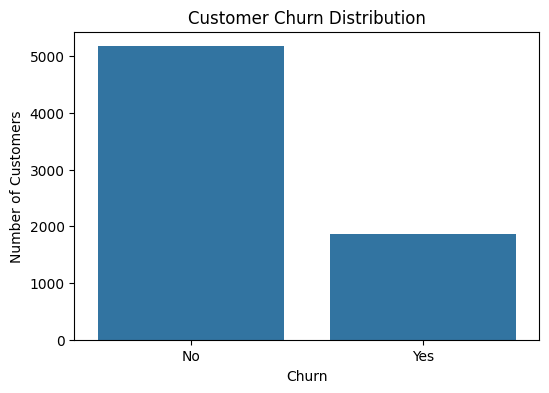

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Percentage of Customers Churned**

In [25]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


**Gender vs Churn**

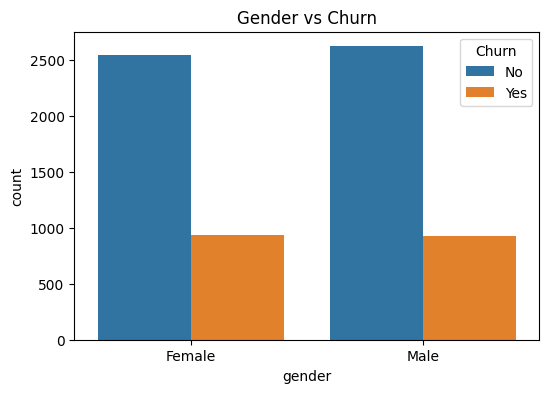

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Churn")

plt.show()


**Senior Citizen vs Churn**

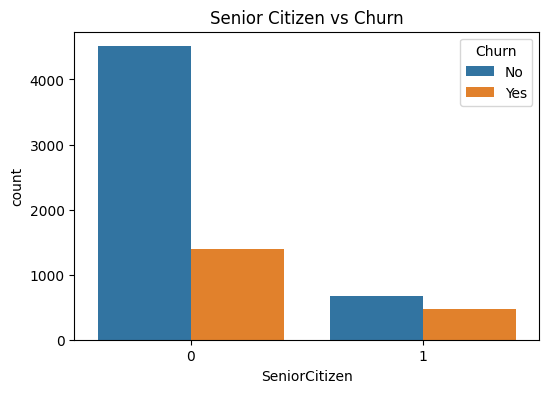

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Churn")

plt.show()

**Contract Type vs Churn**

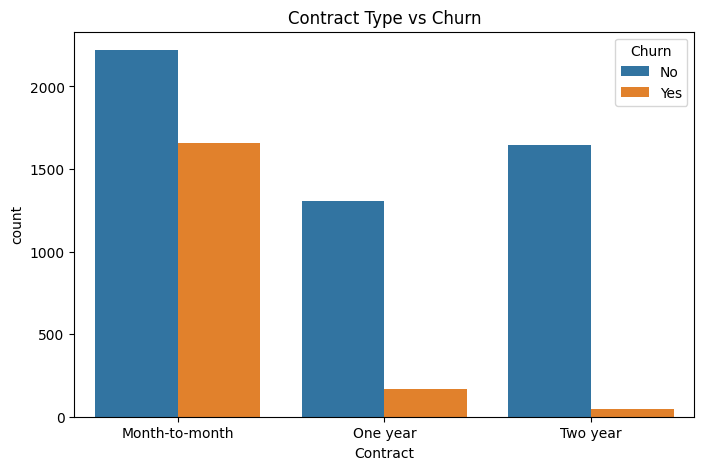

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")

plt.show()

**Internet Service vs Churn**

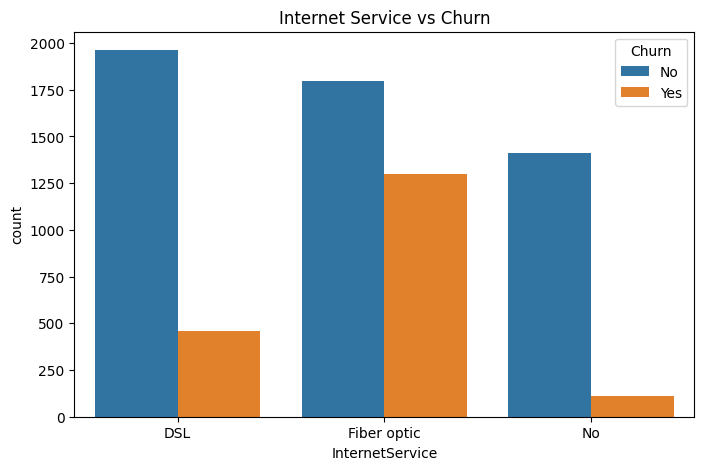

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Churn")

plt.show()

**Payment Method vs Churn**

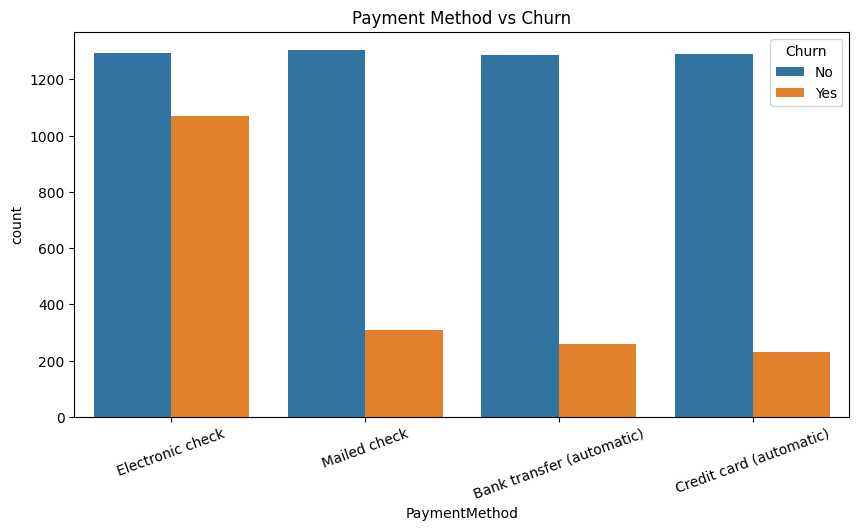

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

**Monthly Charges Distribution**

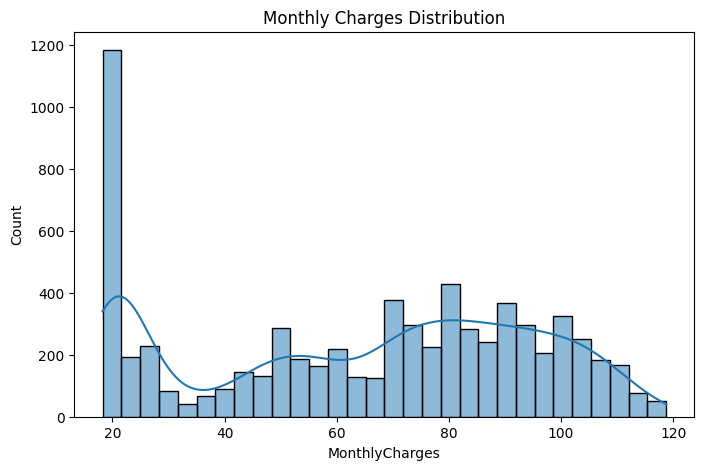

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

**Tenure vs Churn**

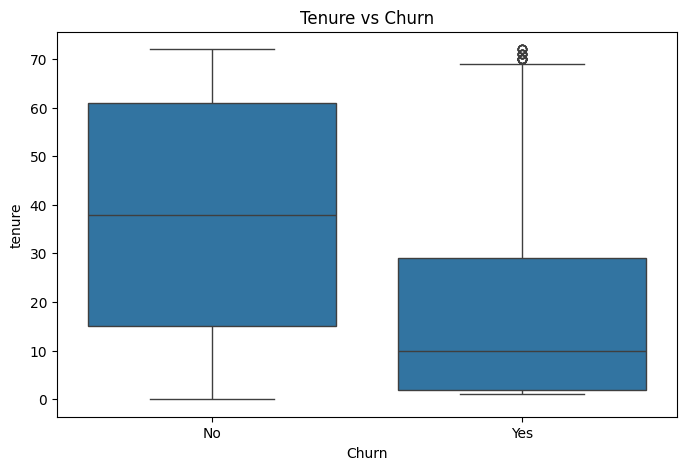

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

**Tenure Distribution**

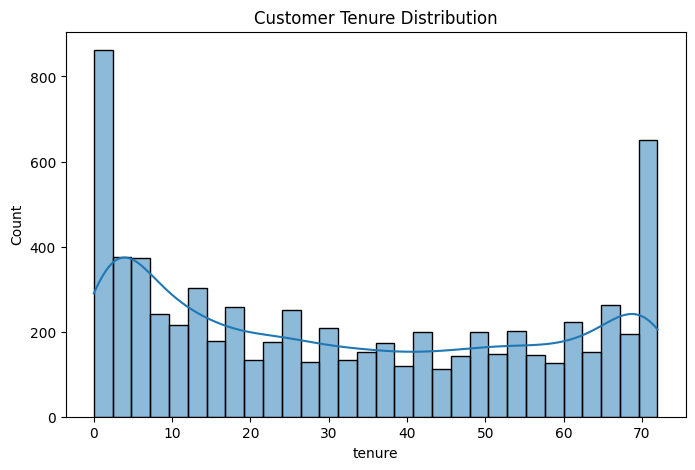

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")

plt.show()

**Monthly Charges vs Churn**

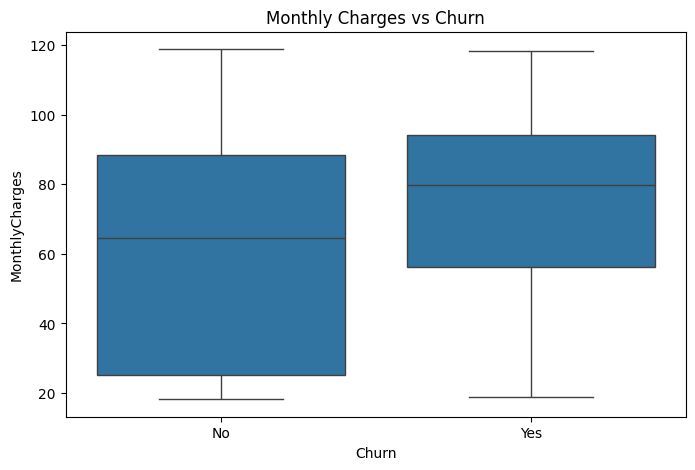

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

**Correlation Heatmap**

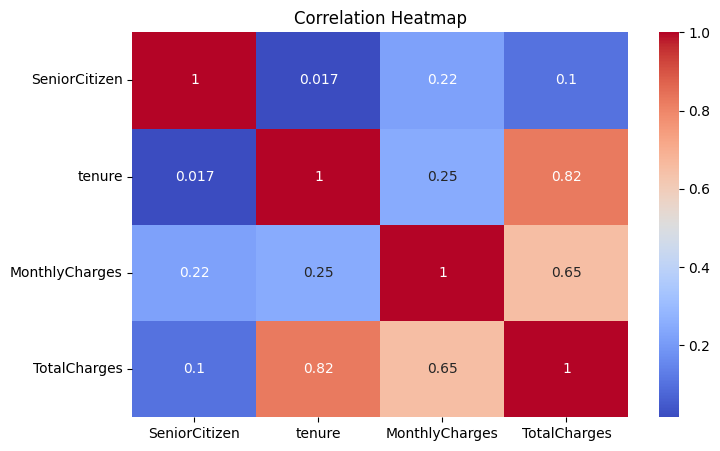

In [35]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# **Training the Model For predicting the Customer Churn**

In [39]:
X=df.drop(['customerID','Churn'],axis=1)

In [40]:
Y=df['Churn']

In [41]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [43]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


In [45]:
x_train.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


# **Performing Label Encoding**

In [46]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

In [51]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for cols in binary_cols:
  x_train[cols]=le.fit_transform(x_train[cols])
  x_test[cols]=le.transform(x_test[cols])
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# **Performing One Hot Encoding**

In [52]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [54]:
x_train = pd.get_dummies(
    x_train,
    columns=multi_cols,
    drop_first=True
)

x_test = pd.get_dummies(
    x_test,
    columns=multi_cols,
    drop_first=True
)

In [55]:
x_train, x_test = x_train.align(
    x_test,
    join='left',
    axis=1,
    fill_value=0
)

In [57]:
print(x_train.head())

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
2142       0              0        0           1      21             1   
1623       0              0        0           0      54             1   
6074       1              0        1           0       1             0   
1362       1              0        0           0       4             1   
6754       1              0        0           1       0             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  \
2142                 0           64.85   1336.800000   
1623                 1           97.20   5129.450000   
6074                 1           23.45     23.450000   
1362                 1           70.20    237.950000   
6754                 1           61.90   2283.300441   

      MultipleLines_No phone service  ...  TechSupport_Yes  \
2142                           False  ...            False   
1623                           False  ...            False   
6074                            

In [59]:
print(x_train.shape)
print(x_test.shape)

(5634, 30)
(1409, 30)


# **Normalising the dataset**

In [60]:
from sklearn.preprocessing import StandardScaler
scaled=StandardScaler()
x_train_scaled=scaled.fit_transform(x_train)
x_test_scaled=scaled.transform(x_test)

# **Using Logistic Regression for Predicting the Customer Chrun**

In [61]:
model=LogisticRegression()

In [62]:
model.fit(x_train_scaled,y_train)


LogisticRegression()

In [63]:
y_pred=model.predict(x_test_scaled)

# **Evaluating the Model trained using Logistic Regression**

In [64]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cf=classification_report(y_test, y_pred)
pre=precision_score(y_test, y_pred)
re=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)

In [71]:
print("========== Logistic Regression Model Evaluation ==========\n")

print(f"Accuracy Score : {round(accuracy,4)*100}%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(cf)

print(f"Precision Score : {round(pre,2)*100}%")
print(f"Recall Score    : {round(re,2)*100}%")
print(f"F1 Score        : {round(f1,2)*100}%")

========== Logistic Regression Model Evaluation ==========

Accuracy Score : 82.04%

Confusion Matrix:
[[934 102]
 [151 222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

Precision Score : 69.0%
Recall Score    : 60.0%
F1 Score        : 64.0%


# **Using KNeighbors Classifier for Predicting the Customer Chrun**

In [73]:
from sklearn.neighbors import KNeighborsClassifier

In [86]:
models=KNeighborsClassifier(n_neighbors=15)
models.fit(x_train_scaled,y_train)
y_preds=models.predict(x_test_scaled)

In [87]:
accuracyK = accuracy_score(y_test, y_preds)
cmK = confusion_matrix(y_test, y_preds)
cfK=classification_report(y_test, y_preds)
preK=precision_score(y_test, y_preds)
reK=recall_score(y_test, y_preds)
f1K=f1_score(y_test, y_preds)

# **Evaluating the Model trained using KNeighbors Classifier**

In [89]:
print("==========KNN Classification Model Evaluation ==========\n")

print(f"Accuracy Score : {round(accuracyK,4)*100}%")

print("\nConfusion Matrix:")
print(cmK)

print("\nClassification Report:")
print(cfK)

print(f"Precision Score : {round(preK,2)*100}%")
print(f"Recall Score    : {round(reK,2)*100}%")
print(f"F1 Score        : {round(f1K,2)*100}%")

==========KNN Classification Model Evaluation ==========

Accuracy Score : 79.63%

Confusion Matrix:
[[917 119]
 [168 205]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.86      1036
           1       0.63      0.55      0.59       373

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Precision Score : 63.0%
Recall Score    : 55.00000000000001%
F1 Score        : 59.0%


# **Influence of features over the Customer Churn**

In [91]:
coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients.head()

,Feature,Coefficient
0,gender,-0.025622
1,SeniorCitizen,0.058275
2,Partner,0.027353
3,Dependents,-0.074943
4,tenure,-1.310326


In [92]:
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print(coefficients)

                                  Feature  Coefficient
11            InternetService_Fiber optic     0.624724
8                            TotalCharges     0.609057
24                    StreamingMovies_Yes     0.231376
22                        StreamingTV_Yes     0.180866
10                      MultipleLines_Yes     0.169119
6                        PaperlessBilling     0.163500
28         PaymentMethod_Electronic check     0.151335
1                           SeniorCitizen     0.058275
9          MultipleLines_No phone service     0.034217
18                   DeviceProtection_Yes     0.028961
2                                 Partner     0.027353
29             PaymentMethod_Mailed check    -0.013147
0                                  gender    -0.025622
5                            PhoneService    -0.034217
27  PaymentMethod_Credit card (automatic)    -0.036289
16                       OnlineBackup_Yes    -0.043821
3                              Dependents    -0.074943
13     Onl

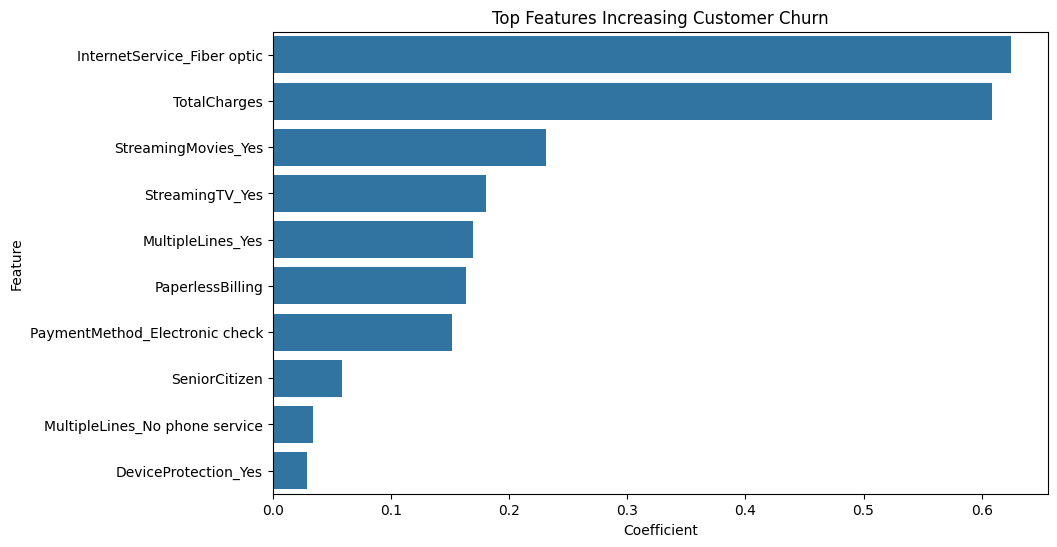

In [93]:
top_positive = coefficients.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=top_positive)

plt.title("Top Features Increasing Customer Churn")

plt.show()

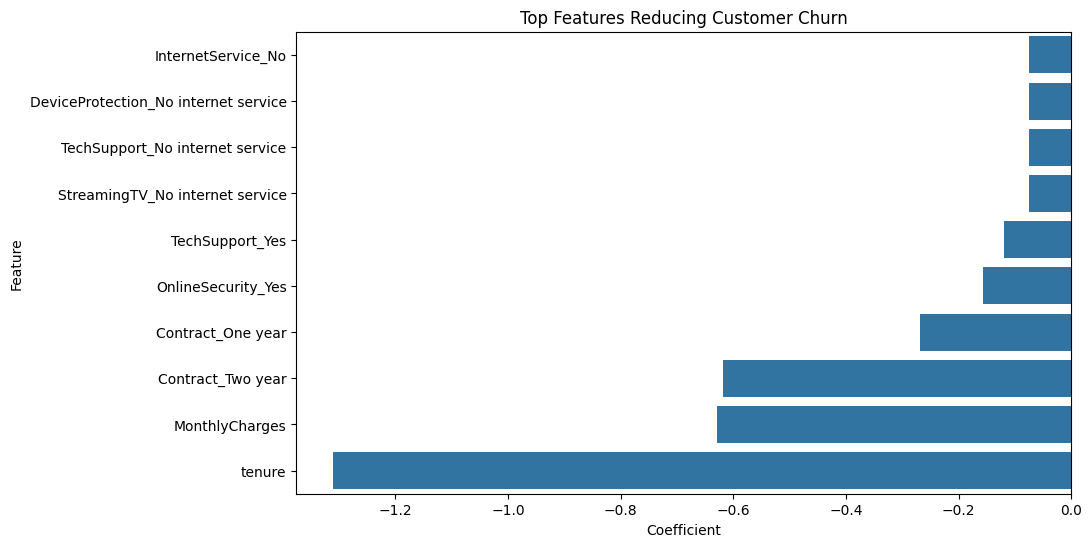

In [94]:
top_negative = coefficients.tail(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=top_negative)

plt.title("Top Features Reducing Customer Churn")

plt.show()

# **Conclusion**

This project focused on predicting customer churn using machine learning techniques. The dataset was first explored and preprocessed by handling missing values, encoding categorical features, and scaling numerical features. Exploratory Data Analysis (EDA) was performed to identify patterns influencing customer churn, revealing that customers with month-to-month contracts, fiber optic internet service, and electronic check payment methods were more likely to churn, while customers with longer tenure and long-term contracts showed better retention.

Two classification algorithms, Logistic Regression and K-Nearest Neighbors (KNN), were implemented and evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. Logistic Regression achieved the best performance with an Accuracy of 82.04%, Precision of 69%, Recall of 60%, and F1-Score of 64%, outperforming the KNN model. Feature importance analysis further provided valuable business insights by identifying the key factors contributing to customer churn.

Overall, this project demonstrates the complete end-to-end machine learning workflow, from data preprocessing and exploratory analysis to model building, evaluation, and interpretation. The developed model can help telecom companies proactively identify customers at risk of leaving and implement targeted retention strategies, ultimately improving customer satisfaction and reducing revenue loss.